# Generated-paper length and model analysis

This notebook analyzes research papers generated by Ollama models and one HuggingFace model (apertus)

## Setup

In [161]:
from pathlib import Path
import json
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nltk

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.grid"] = True


## Choose the generated-paper directory

In [162]:
# Change this path depending on where you have your assembled papers
DATA_DIR = Path("assembled_papers")

if not DATA_DIR.exists():
    print(f"Directory not found: {DATA_DIR.resolve()}")
    print("Update DATA_DIR to point to your assembled_papers_milouche directory.")
else:
    print(f"Using directory: {DATA_DIR.resolve()}")


Using directory: /Users/verce/Desktop/Science des donnes-semsetre 6/Final Project/assembled_papers


## Helper functions

In [163]:
WORD_RE = re.compile(r"\b[a-zA-Z]+(?:[-'][a-zA-Z]+)*\b")

PREFERRED_SECTION_ORDER = [
    "introduction",
    "related_work",
    "background",
    "method",
    "methods",
    "approach",
    "experiments",
    "results",
    "discussion",
    "conclusion",
]

def normalize_text(text: str) -> str:
    if text is None:
        return ""
    text = text.replace("\x00", " ")
    text = text.replace("\r\n", "\n").replace("\r", "\n")
    text = re.sub(r"[ \t]+", " ", text)
    text = re.sub(r"\n{3,}", "\n\n", text)
    return text.strip()

def clean_generated_text(text: str) -> str:
    text = normalize_text(text)

    # Remove simple markdown headings such as "#", "##", etc.
    text = re.sub(r"(?m)^\s{0,3}#{1,6}\s+", "", text)

    # Remove repeated separator-like lines
    text = re.sub(r"(?m)^\s*[-_=]{3,}\s*$", "", text)

    return normalize_text(text)

def count_words(text: str) -> int:
    text = clean_generated_text(text)
    return len(WORD_RE.findall(text))

def find_json_files(data_dir: Path):
    return sorted(
        list(data_dir.rglob("*.json")) + list(data_dir.rglob("*.jsonl"))
    )

def read_records_from_path(path: Path):
    if path.suffix.lower() == ".jsonl":
        records = []
        with path.open("r", encoding="utf-8") as f:
            for line in f:
                line = line.strip()
                if not line:
                    continue
                obj = json.loads(line)
                if isinstance(obj, dict):
                    records.append(obj)
        return records

    with path.open("r", encoding="utf-8") as f:
        obj = json.load(f)

    if isinstance(obj, dict):
        return [obj]
    if isinstance(obj, list):
        return [x for x in obj if isinstance(x, dict)]
    return []

def order_sections(sections: dict, available_sections=None):
    if not isinstance(sections, dict):
        return []

    used = set()
    ordered = []

    if isinstance(available_sections, list):
        for name in available_sections:
            if name in sections:
                ordered.append((name, sections[name]))
                used.add(name)

    for name in PREFERRED_SECTION_ORDER:
        if name in sections and name not in used:
            ordered.append((name, sections[name]))
            used.add(name)

    for name in sections:
        if name not in used:
            ordered.append((name, sections[name]))
            used.add(name)

    return ordered

def build_paper_text(record: dict):
    title = clean_generated_text(record.get("selected_title", ""))
    abstract = clean_generated_text(record.get("abstract", ""))
    sections = record.get("sections", {}) or {}
    available_sections = record.get("available_sections", None)

    ordered_sections = order_sections(sections, available_sections)
    section_texts = [clean_generated_text(text) for _, text in ordered_sections]

    body_text = "\n\n".join([t for t in section_texts if t])
    full_text = "\n\n".join([x for x in [title, abstract, body_text] if x])

    return title, abstract, body_text, full_text, ordered_sections

def record_to_row(record: dict, source_file: str):
    title, abstract, body_text, full_text, ordered_sections = build_paper_text(record)

    row = {
        "source_file": source_file,
        "idea_id": record.get("idea_id"),
        "model": record.get("model") or record.get("generation_model"),
        "topic": record.get("topic"),
        "chosen_direction": record.get("chosen_direction"),
        "refined_problem": record.get("refined_problem"),
        "selected_title": record.get("selected_title"),
        "abstract": abstract,
        "body_text": body_text,
        "full_text": full_text,
        "n_sections_present": len(ordered_sections),
        "available_sections_declared": len(record.get("available_sections", []) or []),
        "missing_sections_declared": len(record.get("missing_sections", []) or []),
        "abstract_word_count": count_words(abstract),
        "body_word_count": count_words(body_text),
        "full_word_count": count_words(full_text),
    }

    for section_name, section_text in ordered_sections:
        safe_name = re.sub(r"[^a-zA-Z0-9_]+", "_", section_name.strip().lower()).strip("_")
        row[f"section__{safe_name}"] = clean_generated_text(section_text)
        row[f"section_words__{safe_name}"] = count_words(section_text)

    return row


## Load generated papers

In [164]:
if DATA_DIR.exists():
    files = find_json_files(DATA_DIR)
    print(f"Found {len(files):,} JSON/JSONL files.")

    rows = []
    for path in files:
        try:
            records = read_records_from_path(path)
            for record in records:
                rows.append(record_to_row(record, str(path.relative_to(DATA_DIR))))
        except Exception as e:
            print(f"Skipping {path.name}: {e}")

    df_gen = pd.DataFrame(rows)
    print(f"Loaded {len(df_gen):,} generated papers.")
    display(df_gen.head(3))
else:
    df_gen = pd.DataFrame()


Found 1,400 JSON/JSONL files.
Loaded 1,400 generated papers.


,source_file,idea_id,model,topic,chosen_direction,refined_problem,selected_title,abstract,body_text,full_text,...,section__related_work,section_words__related_work,section__background,section_words__background,section__method,section_words__method,section__experiments,section_words__experiments,section__conclusion,section_words__conclusion
0,hf_swiss-ai_Apertus-8B-Instruct-2509/idea_001_...,idea_001_02,hf:swiss-ai/Apertus-8B-Instruct-2509,reinforcement learning for continuous control ...,representation learning for planning and reinf...,Learning task-agnostic representations that im...,Task-Agnostic Representation Learning for Hybr...,"In this work, we address the challenge of inte...",The rapid progress in Deep Reinforcement Learn...,Task-Agnostic Representation Learning for Hybr...,...,Related Work\n\nWhile previous works have made...,723,Background\n\nReinforcement Learning (RL) has ...,393,To address the challenge of integrating high-l...,632,Experiments\n1. Evaluation Goal\nThe primary g...,582,"**Conclusion**\n\nIn this work, we address the...",733
1,hf_swiss-ai_Apertus-8B-Instruct-2509/idea_001_...,idea_001_07,hf:swiss-ai/Apertus-8B-Instruct-2509,reinforcement learning for continuous control ...,representation learning for planning and reinf...,Learning task-agnostic representations that im...,Evaluating the Role of Temporal Coherence in U...,Recent advances in reinforcement learning (RL)...,Reinforcement learning (RL) has achieved remar...,Evaluating the Role of Temporal Coherence in U...,...,"In this section, we review prior work related ...",594,Background\n\nRecent advances in reinforcement...,738,"In this work, we propose a novel training obje...",1027,Experiments\n\nThe evaluation of our method is...,834,Conclusion\nSummary of the Problem and Propose...,575
2,hf_swiss-ai_Apertus-8B-Instruct-2509/idea_002_...,idea_002_07,hf:swiss-ai/Apertus-8B-Instruct-2509,generative adversarial networks with adversari...,"unsupervised, semi-supervised, and supervised ...",Developing a semi-supervised generative advers...,Benchmarking Semi-Supervised GANs on Image Cla...,This paper presents a comprehensive benchmarki...,Generative adversarial networks (GANs) have em...,Benchmarking Semi-Supervised GANs on Image Cla...,...,Related Work\n\nGenerative adversarial network...,925,Generative adversarial networks (GANs) have be...,394,To address the challenge of developing a semi-...,865,Experiments\n1. Experimental Setup\n\nThe prop...,598,"Conclusion\n\nIn this paper, we have systemati...",575


In [165]:
MAX_WORDS = 50_000

degenerate = df_gen[df_gen["full_word_count"] > MAX_WORDS]
print(f"Excluding {len(degenerate)} degenerate paper(s):")
display(degenerate[["model", "idea_id", "full_word_count"]])

df_gen = df_gen[df_gen["full_word_count"] <= MAX_WORDS].reset_index(drop=True)
print(f"{len(df_gen):,} papers retained.")

Excluding 1 degenerate paper(s):


,model,idea_id,full_word_count
214,llama3.1:8b,idea_014_04,262413


1,399 papers retained.


## Basic validation

In [166]:
coverage = pd.DataFrame({
    "metric": [
        "generated_papers",
        "models",
        "papers_with_abstract",
        "papers_with_body_text",
        "papers_with_topic",
    ],
    "value": [
        len(df_gen),
        df_gen["model"].nunique(dropna=True),
        df_gen["abstract"].astype(bool).sum(),
        df_gen["body_text"].astype(bool).sum(),
        df_gen["topic"].notna().sum(),
    ],
})

display(coverage)

papers_per_model = (
    df_gen["model"]
    .value_counts(dropna=False)
    .rename_axis("model")
    .reset_index(name="n_papers")
)

display(papers_per_model)

,metric,value
0,generated_papers,1399
1,models,7
2,papers_with_abstract,1399
3,papers_with_body_text,1399
4,papers_with_topic,1399


,model,n_papers
0,hf:swiss-ai/Apertus-8B-Instruct-2509,200
1,phi4-reasoning:14b,200
2,qwen2.5:7b,200
3,qwen3:14b,200
4,qwen3.5:9b,200
5,qwen3:8b,200
6,llama3.1:8b,199


## Summary statistics of paper length by model


In [167]:
if len(df_gen) > 0:
    summary_by_model = (
        df_gen.groupby("model")["full_word_count"]
        .agg(["count", "mean", "median", "min", "max", "std"])
        .sort_values("count", ascending=False)
    )
    display(summary_by_model)

    overall_summary = df_gen["full_word_count"].agg(["count", "mean", "median", "min", "max", "std"])
    display(overall_summary.to_frame("overall"))


,count,mean,median,min,max,std
model,,,,,,
hf:swiss-ai/Apertus-8B-Instruct-2509,200,3989.680000,3961.5,3313,5049,316.123056
phi4-reasoning:14b,200,11464.810000,11368.5,9544,14447,935.147141
qwen2.5:7b,200,2791.390000,2781.5,2365,3315,160.511331
qwen3.5:9b,200,6187.840000,6211.5,5131,7068,308.408354
qwen3:14b,200,5990.950000,5990.0,5385,6897,260.916509
qwen3:8b,200,6845.450000,6844.5,5938,7865,348.315930
llama3.1:8b,199,3051.291457,3044.0,2584,3823,200.805790


,overall
count,1399.000000
mean,5762.137956
median,5875.000000
min,2365.000000
max,14447.000000
std,2792.917613


## Inspect the longest and shortest generated papers

In [168]:
if len(df_gen) > 0:
    display(df_gen.nlargest(5, "full_word_count")[[
        "model", "idea_id", "topic", "selected_title", "full_word_count"
    ]])

    display(df_gen.nsmallest(5, "full_word_count")[[
        "model", "idea_id", "topic", "selected_title", "full_word_count"
    ]])


,model,idea_id,topic,selected_title,full_word_count
547,phi4-reasoning:14b,idea_143_06,graph convolutional networks for node classifi...,A Theoretical Framework for Understanding Opti...,14447
481,phi4-reasoning:14b,idea_073_06,feature selection in deep learning,Semi-Supervised Feature Selection via Gradient...,14005
564,phi4-reasoning:14b,idea_165_04,weakly supervised learning for vision,Semi-Supervised Representation Learning with E...,13978
562,phi4-reasoning:14b,idea_164_01,activation function design for deep learning,Gradient-Enhancing Activation Functions for Im...,13611
425,phi4-reasoning:14b,idea_022_04,non-convex optimization in deep learning,Escaping Saddle Points via Adaptive Momentum i...,13538


,model,idea_id,topic,selected_title,full_word_count
674,qwen2.5:7b,idea_090_04,dimensionality reduction with autoencoders,Latent Space Disentanglement through Orthogona...,2365
754,qwen2.5:7b,idea_153_04,density estimation with normalizing flows,Layer-Wise Variational Inference for Training ...,2413
644,qwen2.5:7b,idea_054_04,word embeddings in language understanding,Theoretical Analysis of Gradient Flow in Semi-...,2485
705,qwen2.5:7b,idea_116_03,summarization with transformer models,Modular Hierarchical Transformers for Document...,2493
695,qwen2.5:7b,idea_111_01,Bayesian neural networks for uncertainty,Bayesian Uncertainty-Aware State Embeddings fo...,2494


## Paper length distribution per model

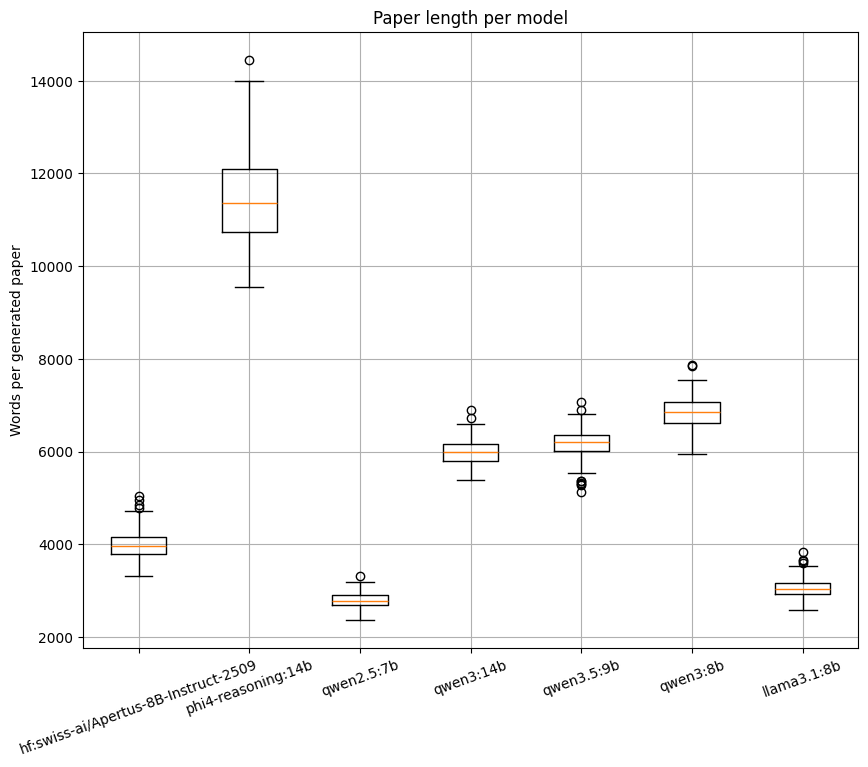

In [169]:
if len(df_gen) > 0:
    df_plot = df_gen[df_gen["full_word_count"] <= 15000]

    ordered_models = (
        df_plot["model"]
        .value_counts()
        .index
        .tolist()
    )

    data = [df_plot.loc[df_plot["model"] == model_name, "full_word_count"].dropna().to_numpy()
        for model_name in ordered_models
    ]

    fig, ax = plt.subplots(figsize=(10, 8))
    ax.boxplot(data, tick_labels=ordered_models)
    ax.set_title("Paper length per model")
    ax.set_ylabel("Words per generated paper")
    plt.xticks(rotation=20)
    plt.show()

# Sentence inspaction

* Sentence segmentation is regex-based and approximate

In [170]:
SENTENCE_SPLIT_RE = re.compile(r'[.!?]+(?:\s+|$)')

def split_sentences(text):
    if not isinstance(text, str):
        return []
    return [s.strip() for s in SENTENCE_SPLIT_RE.split(text) if s.strip()]

def compute_sentence_stats(text):
    lengths = [len(s.split()) for s in split_sentences(text)]
    if not lengths:
        return {"sentence_count": 0, "mean_sentence_length": 0,
                "median_sentence_length": 0, "std_sentence_length": 0,
                "max_sentence_length": 0}
    return {
        "sentence_count": len(lengths),
        "mean_sentence_length": np.mean(lengths),
        "median_sentence_length": np.median(lengths),
        "std_sentence_length": np.std(lengths),
        "max_sentence_length": np.max(lengths),
    }

# sentence stats on the full paper text (this is what Flesch / coherence / the ICLR
# comparison actually use)
full_stats = (df_gen["full_text"].apply(compute_sentence_stats)
              .apply(pd.Series).add_prefix("full_"))
df_sentence = pd.concat([df_gen, full_stats], axis=1)

# --- summary table: sentence length by model ---
sentence_summary = (
    df_sentence.groupby("model")
    .agg(
        n_papers=("model", "size"),
        mean_sentence_length=("full_mean_sentence_length", "mean"),
        median_sentence_length=("full_median_sentence_length", "mean"),
        std_sentence_length=("full_std_sentence_length", "mean"),
        mean_sentence_count=("full_sentence_count", "mean"),
    )
    .round(2)
    .sort_values("mean_sentence_length")
)
display(sentence_summary)

,n_papers,mean_sentence_length,median_sentence_length,std_sentence_length,mean_sentence_count
model,,,,,
phi4-reasoning:14b,200,20.36,20.16,9.74,568.56
hf:swiss-ai/Apertus-8B-Instruct-2509,200,21.06,21.84,9.32,193.53
qwen2.5:7b,200,22.39,22.28,7.55,126.40
llama3.1:8b,199,22.43,22.03,7.97,138.27
qwen3.5:9b,200,23.05,22.65,6.20,268.73
qwen3:8b,200,24.94,24.71,6.14,274.05
qwen3:14b,200,26.15,25.96,6.76,228.89


## Lexical diversity and repetition 


In [171]:
def ttr(text, cap=2000):
    w = WORD_RE.findall(text.lower()) if isinstance(text, str) else []
    w = w[:cap]
    return len(set(w)) / len(w) if w else np.nan

def rep_ngram(text, n=3):
    w = WORD_RE.findall(text.lower()) if isinstance(text, str) else []
    if len(w) < n + 1:
        return np.nan
    g = [tuple(w[i:i+n]) for i in range(len(w) - n + 1)]
    return 1 - len(set(g)) / len(g)

df_gen["ttr"]  = df_gen["full_text"].apply(ttr)
df_gen["rep3"] = df_gen["full_text"].apply(rep_ngram)

display(df_gen.groupby("model")[["ttr", "rep3"]].agg(["mean", "median"]).round(3))

ttr          rep3       
                                       mean median   mean median
model                                                           
hf:swiss-ai/Apertus-8B-Instruct-2509  0.224  0.225  0.311  0.307
llama3.1:8b                           0.229  0.230  0.320  0.321
phi4-reasoning:14b                    0.285  0.285  0.224  0.223
qwen2.5:7b                            0.256  0.256  0.218  0.219
qwen3.5:9b                            0.313  0.312  0.174  0.174
qwen3:14b                             0.288  0.288  0.202  0.201
qwen3:8b                              0.273  0.273  0.245  0.244

## Citation check


In [172]:
CITE_RE = re.compile(r"\[\d{1,3}(?:\s*[,-]\s*\d{1,3})*\]"
                     r"|\([A-Z][A-Za-z]+(?: et al\.?)?,?\s+\d{4}[a-z]?\)")

df_gen["n_citations"] = df_gen["full_text"].apply(
    lambda t: len(CITE_RE.findall(t)) if isinstance(t, str) else 0)
df_gen["has_citations"] = df_gen["n_citations"] > 0

display(df_gen.groupby("model")
        .agg(mean_citations=("n_citations", "mean"),
             median_citations=("n_citations", "median"),
             pct_with_citations=("has_citations", "mean"))
        .round(2).sort_values("mean_citations", ascending=False))


,mean_citations,median_citations,pct_with_citations
model,,,
hf:swiss-ai/Apertus-8B-Instruct-2509,6.12,5.0,0.92
llama3.1:8b,4.20,4.0,0.91
qwen2.5:7b,4.14,4.0,0.85
qwen3:8b,3.18,2.0,0.60
qwen3:14b,1.62,0.0,0.42
phi4-reasoning:14b,0.44,0.0,0.22
qwen3.5:9b,0.07,0.0,0.04


### Extracted individual citation (for manual inspection)

In [173]:
def extract_citation_contexts(text, pattern=CITE_RE, window=80):
    contexts = []
    if not isinstance(text, str):
        return contexts
    for m in pattern.finditer(text):
        start, end = m.span()
        left = text[max(0, start - window):start].replace("\n", " ")
        right = text[end:end + window].replace("\n", " ")
        contexts.append({
            "citation": m.group(0),
            "context": f"...{left.strip()} >>>{m.group(0)}<<< {right.strip()}...",
        })
    return contexts

citation_rows = []
for _, row in df_gen.iterrows():
    for c in extract_citation_contexts(row["full_text"]):
        citation_rows.append({
            "source_file": row["source_file"],
            "model": row["model"],
            "selected_title": row["selected_title"],
            "citation": c["citation"],
            "context": c["context"],
        })

df_citations = pd.DataFrame(citation_rows)
print(f"Extracted {len(df_citations):,} citation instances "
      f"from {df_citations['source_file'].nunique() if len(df_citations) else 0} papers.")

citation_counts = (
    df_citations["citation"].value_counts()
    .rename_axis("citation")
    .reset_index(name="n_occurrences")
)
display(citation_counts.head(30))

sample_citations = df_citations.sample(n=min(20, len(df_citations)), random_state=42) if len(df_citations) else df_citations
display(sample_citations)

df_citations.to_csv("extracted_citations_for_review.csv", index=False)



Extracted 3,949 citation instances from 789 papers.


,citation,n_occurrences
0,[1],98
1,[2],88
2,[3],68
3,"(Chen et al., 2020)",59
4,"(Snell et al., 2017)",56
5,[4],51
6,"(Chen et al., 2018)",48
7,"(Vaswani et al., 2017)",39
8,"(Zhang et al., 2018)",36
9,"(Higgins et al., 2017)",35


,source_file,model,selected_title,citation,context
3136,qwen3_14b/idea_110_07.json,qwen3:14b,Generalization-Driven Curriculum Learning for ...,"(Schaul et al., 2016)","...and learning stability. Early approaches, s..."
2118,phi4-reasoning_14b/idea_143_03.json,phi4-reasoning:14b,Regularization via Graph Topology-Aware Loss F...,"(Monti et al., 2017)","..., 2016), GCN (Kipf & Welling, 2017) as well..."
1811,llama3_1_8b/idea_147_05.json,llama3.1:8b,Empirical Evaluation of Second-Order Methods f...,"(Wilson et al., 2017)",...rovide higher-quality updates but come with...
70,hf_swiss-ai_Apertus-8B-Instruct-2509/idea_013_...,hf:swiss-ai/Apertus-8B-Instruct-2509,Hierarchical Metric Learning with Transformers...,"(Fan et al., 2018)","...examples and 30 evaluation examples, also b..."
2609,qwen2_5_7b/idea_120_03.json,qwen2.5:7b,Contrastive Learning with Adversarial Augmenta...,"(Madry et al., 2017)","...limitations. For instance, while extensive ..."
3489,qwen3_8b/idea_056_03.json,qwen3:8b,Analyzing the Role of Unsupervised Pre-trainin...,"(Devlin et al., 2018)",...beled and unlabeled data. Early work on uns...
1694,llama3_1_8b/idea_122_05.json,llama3.1:8b,Stochastic Mirror Descent for Robust Latent Sp...,"(Pang et al., 2020)",...een explored as a means to improve standard...
3309,qwen3_5_9b/idea_167_02.json,qwen3.5:9b,Structured Optimization for Long-Term Video Pr...,"(Buesing et al., 2018)",...r using state estimation models that predic...
270,hf_swiss-ai_Apertus-8B-Instruct-2509/idea_046_...,hf:swiss-ai/Apertus-8B-Instruct-2509,Comparing Batch Normalization and Layer Normal...,[1],...role in improving optimization and generali...
1270,llama3_1_8b/idea_008_01.json,llama3.1:8b,Adaptive Margin Contrastive Learning for Cross...,[6],...d embeddings jointly with a word alignment ...


## Readibility metrics - Flesch score

In [174]:
def count_syllables(word):
    word = word.lower()
    word = re.sub(r'[^a-z]', '', word)

    if len(word) == 0:
        return 0

    vowels = "aeiouy"
    syllables = 0
    prev_char_was_vowel = False

    for char in word:
        is_vowel = char in vowels
        if is_vowel and not prev_char_was_vowel:
            syllables += 1
        prev_char_was_vowel = is_vowel

    # silent 'e'
    if word.endswith("e"):
        syllables = max(1, syllables - 1)

    return max(1, syllables)

In [175]:
def flesch_reading_ease_simple(text):
    if not isinstance(text, str) or len(text.strip()) == 0:
        return np.nan

    sentences = split_sentences(text)
    words = re.findall(r"\b[\w'-]+\b", text)

    if len(sentences) == 0 or len(words) == 0:
        return np.nan

    syllable_count = sum(count_syllables(w) for w in words)

    words_per_sentence = len(words) / len(sentences)
    syllables_per_word = syllable_count / len(words)

    flesch = 206.835 - 1.015 * words_per_sentence - 84.6 * syllables_per_word
    return flesch

In [176]:
# Flesch by model (summary)
df_sentence["full_flesch"] = df_sentence["full_text"].apply(flesch_reading_ease_simple)
display(df_sentence.groupby("model")["full_flesch"].agg(["mean", "median", "std"]).round(2))


,mean,median,std
model,,,
hf:swiss-ai/Apertus-8B-Instruct-2509,7.49,7.29,5.31
llama3.1:8b,3.17,3.57,5.36
phi4-reasoning:14b,9.00,9.29,3.40
qwen2.5:7b,1.40,1.23,4.68
qwen3.5:9b,1.46,1.73,3.54
qwen3:14b,-1.83,-2.14,4.36
qwen3:8b,-0.50,-0.59,3.99


## Do models differ? (significance test)

- One Kruskal-Wallis test per metric. p < 0.05 


In [177]:
from scipy import stats

def kruskal_by_model(df, col):
    groups = [g[col].dropna() for _, g in df.groupby("model") if g[col].notna().sum() > 1]
    if len(groups) < 2:
        return (np.nan, np.nan)
    h, p = stats.kruskal(*groups)
    return (round(h, 2), p)

rows = []
for name, frame, col in [
    ("full_word_count", df_gen, "full_word_count"),
    ("ttr",             df_gen, "ttr"),
    ("rep3",            df_gen, "rep3"),
    ("flesch",          df_sentence, "full_flesch")
]:
    h, p = kruskal_by_model(frame, col)
    rows.append({"metric": name, "H": h, "p_value": p})
display(pd.DataFrame(rows))


,metric,H,p_value
0,full_word_count,1323.08,1.091805e-282
1,ttr,1146.19,2.109778e-244
2,rep3,1076.01,3.239873e-229
3,flesch,583.96,6.706651e-123


# Comparison with real ICLR papers

In [178]:
# ICLR reference from iclr_dataset_analysis.ipynb
ICLR_REF = {
    "body_words":      (4667.66, 771.88),
    "sentence_length": (21.17,     2.63),
    "flesch":          (38.84,     6.47),
    "ttr":             (0.296,     0.028),
    "rep3":            (0.113,     0.035),
    "citations":       (14.46,    10.59)
}
iclr_mean = pd.Series({k: v[0] for k, v in ICLR_REF.items()})
iclr_std  = pd.Series({k: v[1] for k, v in ICLR_REF.items()})

gen = pd.DataFrame({
    "body_words":      df_gen.groupby("model")["full_word_count"].mean(),
    "sentence_length": df_sentence.groupby("model")["full_mean_sentence_length"].mean(),
    "flesch":          df_sentence.groupby("model")["full_flesch"].mean(),
    "ttr":             df_gen.groupby("model")["ttr"].mean(),
    "rep3":            df_gen.groupby("model")["rep3"].mean(),
    "citations":       df_gen.groupby("model")["n_citations"].mean(),
})

gen = gen[list(ICLR_REF)]

compare = pd.concat([iclr_mean.rename("ICLR"), gen.T], axis=1).round(3)
print("Table 1: Mean value per metric (first column = real ICLR):")
display(compare)

pct  = ((gen - iclr_mean) / iclr_mean * 100)          
zabs = ((gen - iclr_mean) / iclr_std).abs()          

iclr_vs_generated = pct.round(1).copy()
iclr_vs_generated["closeness_score"] = zabs.mean(axis=1).round(2)   
iclr_vs_generated = iclr_vs_generated.sort_values("closeness_score")

print("\nTable 2: closeness_score")
display(iclr_vs_generated)

Table 1: Mean value per metric (first column = real ICLR):


,ICLR,hf:swiss-ai/Apertus-8B-Instruct-2509,llama3.1:8b,phi4-reasoning:14b,qwen2.5:7b,qwen3.5:9b,qwen3:14b,qwen3:8b
body_words,4667.660,3989.680,3051.291,11464.810,2791.390,6187.840,5990.950,6845.450
sentence_length,21.170,21.060,22.431,20.363,22.389,23.054,26.153,24.936
flesch,38.840,7.491,3.167,8.996,1.401,1.459,-1.826,-0.499
ttr,0.296,0.224,0.229,0.285,0.256,0.313,0.288,0.273
rep3,0.113,0.311,0.320,0.224,0.218,0.174,0.202,0.245
citations,14.460,6.115,4.201,0.445,4.135,0.070,1.620,3.180



Table 2: closeness_score


,body_words,sentence_length,flesch,ttr,rep3,citations,closeness_score
model,,,,,,,
qwen3.5:9b,32.6,8.9,-96.2,5.9,53.7,-99.5,2.03
qwen3:14b,28.4,23.5,-104.7,-2.8,78.6,-88.8,2.32
qwen2.5:7b,-40.2,5.8,-96.4,-13.6,92.8,-71.4,2.35
hf:swiss-ai/Apertus-8B-Instruct-2509,-14.5,-0.5,-80.7,-24.2,175.5,-57.7,2.46
qwen3:8b,46.7,17.8,-101.3,-7.9,116.5,-78.0,2.67
llama3.1:8b,-34.6,6.0,-91.8,-22.7,183.2,-70.9,2.90
phi4-reasoning:14b,145.6,-3.8,-76.8,-3.6,98.3,-96.9,3.10
